In [7]:
# Import libraries
import pandas as pd
import requests
import anthropic
import urllib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

In [8]:
# Connection to Azure SQL
load_dotenv()

conn = urllib.parse.quote_plus(
    f"DRIVER=ODBC Driver 17 for SQL Server;"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')}"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={conn}")
print("Connected to Azure SQL!")

Connected to Azure SQL!


In [9]:
# Pull revenue by state
df_revenue = pd.read_sql("""
    SELECT
		c.customer_state,
		COUNT(DISTINCT o.order_id) AS total_orders,
		ROUND(SUM(p.payment_value), 2) AS total_revenue
	FROM olist_orders_dataset o
	JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
	JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
	WHERE o.order_status = 'delivered'
	GROUP BY c.customer_state
	ORDER BY total_revenue DESC
""", engine)

df_revenue.head(5)

,customer_state,total_orders,total_revenue
0,SP,40500,5770266.19
1,RJ,12350,2055690.45
2,MG,11354,1819277.61
3,RS,5345,861802.40
4,PR,4923,781919.55


In [11]:
# Import missing library
import json

url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2021/variaveis/9324?localidades=N3[all]"

response = requests.get(url, timeout = 15)
response.raise_for_status()
data = response.json()

print("Status: ", response.status_code)
print("Rows returned: ", len(data))

if data:
    print(json.dumps(data[0], indent = 2, ensure_ascii = False))
else:
    print("No data returned for this aggregate/period/variable combination.")

Status:  200
Rows returned:  1
{
  "id": "9324",
  "variavel": "População residente estimada",
  "unidade": "Pessoas",
  "resultados": [
    {
      "classificacoes": [],
      "series": [
        {
          "localidade": {
            "id": "11",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Rondônia"
          },
          "serie": {
            "2021": "1815278"
          }
        },
        {
          "localidade": {
            "id": "12",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Acre"
          },
          "serie": {
            "2021": "906876"
          }
        },
        {
          "localidade": {
            "id": "13",
            "nivel": {
              "id": "N3",
              "nome": "Unidade da Federação"
            },
            "nome": "Amazonas"
          },
          "serie": {
        

In [12]:
# Pull population data from IBGE API
state_map = {
    "11":"RO","12":"AC","13":"AM","14":"RR","15":"PA",
    "16":"AP","17":"TO","21":"MA","22":"PI","23":"CE",
    "24":"RN","25":"PB","26":"PE","27":"AL","28":"SE",
    "29":"BA","31":"MG","32":"ES","33":"RJ","35":"SP",
    "41":"PR","42":"SC","43":"RS","50":"MS","51":"MT",
    "52":"GO","53":"DF"
}

rows = []

for code, uf in state_map.items():
    url = f"https://servicodados.ibge.gov.br/api/v1/pesquisas/indicadores/29171/resultados/{code}"
    try:
        r = requests.get(url, timeout = 15)
        r.raise_for_status()
        payload = r.json()

        res = payload[0]['res'][0]['res']
        rows.append({
            "state_code": code,
            "customer_state": uf,
            "population_2024": int(res.get("2024")) if res.get("2024") else None,
            "population_2025": int(res.get("2025")) if res.get("2025") else None,
        })
        print(f'{uf}: OK')

    except Exception as e:
        print(f"{uf}: Failed - {e}")

df_population = pd.DataFrame(rows)
print(df_population)

RO: OK
AC: OK
AM: OK
RR: OK
PA: OK
AP: OK
TO: OK
MA: OK
PI: OK
CE: OK
RN: OK
PB: OK
PE: OK
AL: OK
SE: OK
BA: OK
MG: OK
ES: OK
RJ: OK
SP: OK
PR: OK
SC: OK
RS: OK
MS: OK
MT: OK
GO: OK
DF: OK
   state_code customer_state  population_2024  population_2025
0          11             RO          1746227          1751950
1          12             AC           880631           884372
2          13             AM          4281209          4321616
3          14             RR           716793           738772
4          15             PA          8664306          8711196
5          16             AP           802837           806517
6          17             TO          1577342          1586859
7          21             MA          7010960          7018211
8          22             PI          3375646          3384547
9          23             CE          9233656          9268836
10         24             RN          3446071          3455236
11         25             PB          4145040          

In [13]:
# Parsing the API response
records = []

for item in data:
    for res in item.get("resultados", []):
        for loc in res.get("series", []):
            state_id = loc["localidade"]["id"]
            state_code = state_map.get(state_id, state_id)

            values = loc["serie"]
            latest_year = max(values.keys())
            population = int(values[latest_year])

            records.append({
                "customer_state": state_code,
                "population": population
            })

df_population = pd.DataFrame(records)
print(df_population.head())

  customer_state  population
0             RO     1815278
1             AC      906876
2             AM     4269995
3             RR      652713
4             PA     8777124


In [14]:
# Merging both sources in Pandas
df_combined = pd.merge(
    df_revenue,
    df_population,
    on = 'customer_state',
    how = 'inner'
)

# Calculate revenue per capita
df_combined["revenue_per_capita"] = (
    df_combined["total_revenue"] / df_combined["population"]
).round(4)

# Sort revenue per capita
df_combined = df_combined.sort_values("revenue_per_capita", ascending = False)

print(f"Combined: {len(df_combined)} states")
print(df_combined[["customer_state","total_revenue","population","revenue_per_capita"]])

Combined: 27 states
   customer_state  total_revenue  population  revenue_per_capita
0              SP     5770266.19    46649132              0.1237
1              RJ     2055690.45    17463349              0.1177
7              DF      346146.17     3094325              0.1119
2              MG     1819277.61    21411923              0.0850
5              SC      595208.40     7338473              0.0811
9              ES      317682.65     4108508              0.0773
3              RS      861802.40    11466630              0.0752
4              PR      781919.55    11597484              0.0674
13             MT      181441.72     3567234              0.0509
16             MS      134421.54     2839188              0.0473
8              GO      334294.22     7206589              0.0464
6              BA      591270.60    14985284              0.0395
21             TO       60007.37     1607363              0.0373
15             PB      137834.65     4059905              0.0340
17   

In [15]:
# Connecting to Claude API
load_dotenv(override = True)

key = os.getenv("ANTHROPIC_API_KEY")
print("Key loaded:", key[:10] + "..." if key else "NOT FOUND")

Key loaded: sk-ant-api...


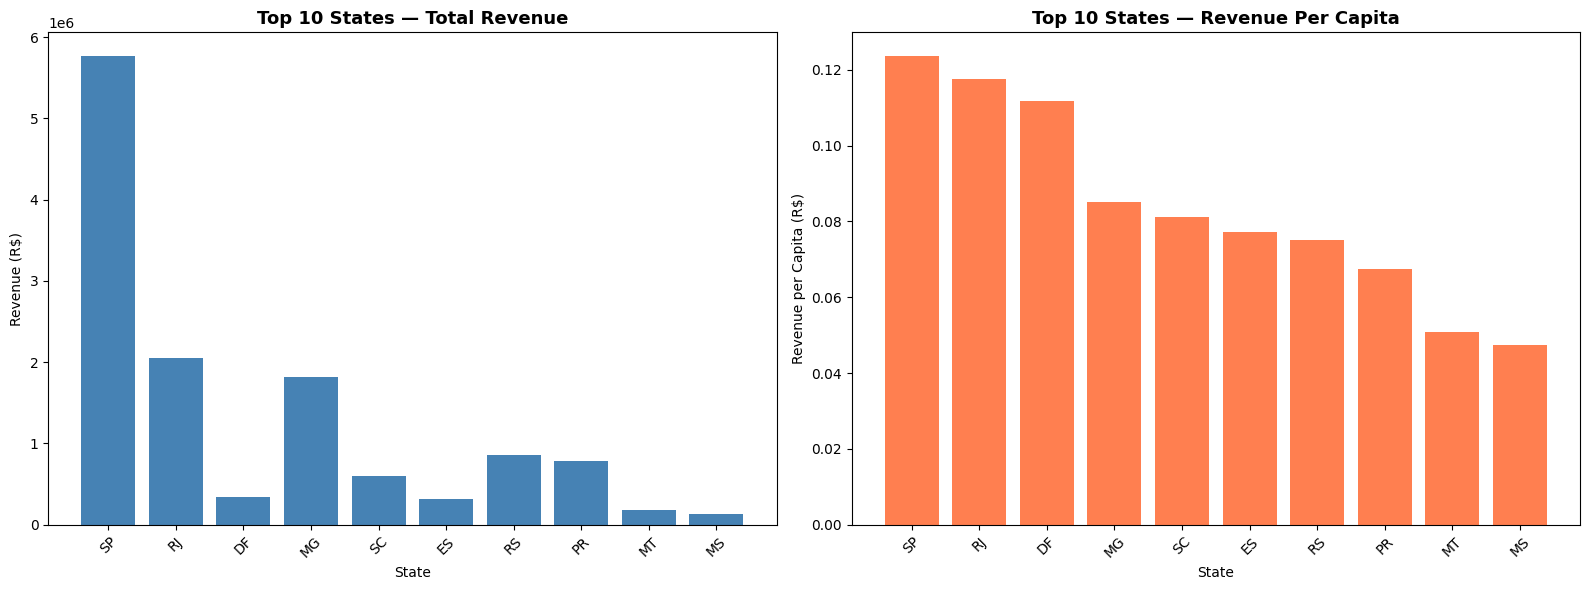

Charts saved to olist_state_analysis.png


In [18]:
# Two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top10 = df_combined.head(10)

# Chart 1 — Total revenue by state
ax1.bar(top10["customer_state"], top10["total_revenue"], color="steelblue")
ax1.set_title("Top 10 States — Total Revenue", fontweight="bold", fontsize=13)
ax1.set_xlabel("State")
ax1.set_ylabel("Revenue (R$)")
ax1.tick_params(axis="x", rotation=45)

# Chart 2 — Revenue per capita
ax2.bar(top10["customer_state"], top10["revenue_per_capita"], color="coral")
ax2.set_title("Top 10 States — Revenue Per Capita", fontweight="bold", fontsize=13)
ax2.set_xlabel("State")
ax2.set_ylabel("Revenue per Capita (R$)")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("images/olist_state_analysis.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("Charts saved to olist_state_analysis.png")